# Klassieke Detectie Tuning – Dataset A

Interactief tunen van HSV-drempelwaarden en geometrische filters voor de klassieke detectie-pipeline op de atletiekpiste.

> **Vereisten:**
> - Video `Atletiekpiste.mp4` (zie `data/README.md`)
> - Bibliotheken: `opencv-python`, `numpy`, `matplotlib`, `ipywidgets`
>
> **Werkwijze:** Voer cel 2 uit om de optimale HSV-drempelwaarden te bepalen. Noteer de waarden en gebruik ze vervolgens in `3-Evaluatie-Visualisatie.ipynb`.

### Initialisatie

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

# Pad naar de video (pas aan indien nodig)
VIDEO_PATH = "../../data/video/Atletiekpiste.mp4"

# Frame voor tuning: kies bij voorkeur een frame met gevarieerde belichting
TUNING_FRAME = 255

print("Bibliotheken geladen.")

Bibliotheken geladen.


### Tuning van HSV-waarden

In [4]:
def show_hsv_tuning(l_h, l_s, l_v, u_h, u_s, u_v):
    cap = cv2.VideoCapture(VIDEO_PATH)
    cap.set(cv2.CAP_PROP_POS_FRAMES, TUNING_FRAME)
    ret, frame = cap.read()
    cap.release()
    
    if not ret:
        return
        
    blurred = cv2.GaussianBlur(frame, (5, 5), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
    lower = np.array([l_h, l_s, l_v])
    upper = np.array([u_h, u_s, u_v])
    mask = cv2.inRange(hsv, lower, upper)
    
    # Morfologische ruisonderdrukking
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=2)
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax[0].set_title(f"Origineel (Frame {TUNING_FRAME})")
    ax[0].axis("off")
    
    ax[1].imshow(mask, cmap="gray")
    ax[1].set_title(f"Detectiemasker | HSV: [{l_h},{l_s},{l_v}] – [{u_h},{u_s},{u_v}]")
    ax[1].axis("off")
    
    plt.tight_layout()
    plt.show()

print("Stel de sliders in tot de magenta petjes wit zijn en de achtergrond zwart.")

interact(
    show_hsv_tuning,
    l_h=IntSlider(min=0, max=179, step=1, value=140, description="L Hue"),
    l_s=IntSlider(min=0, max=255, step=1, value=50, description="L Sat"),
    l_v=IntSlider(min=0, max=255, step=1, value=50, description="L Val"),
    u_h=IntSlider(min=0, max=179, step=1, value=165, description="U Hue"),
    u_s=IntSlider(min=0, max=255, step=1, value=255, description="U Sat"),
    u_v=IntSlider(min=0, max=255, step=1, value=255, description="U Val"),
);

Stel de sliders in tot de magenta petjes wit zijn en de achtergrond zwart.


interactive(children=(IntSlider(value=140, description='L Hue', max=179), IntSlider(value=50, description='L S…

### Tuning van parameters

In [ ]:
# Definitieve HSV-waarden – invullen na tuning in cel 2
L_HSV = np.array([140, 50, 50])
U_HSV = np.array([165, 255, 255])

def tune_geometric_filters(min_area, max_area, min_ratio, max_ratio):
    cap = cv2.VideoCapture(VIDEO_PATH)
    cap.set(cv2.CAP_PROP_POS_FRAMES, TUNING_FRAME)
    ret, frame_orig = cap.read()
    cap.release()
    
    if not ret:
        return
        
    blurred = cv2.GaussianBlur(frame_orig, (5, 5), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, L_HSV, U_HSV)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=2)
    
    output_img = frame_orig.copy()
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    n_accepted = 0
    n_rejected = 0
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 10:
            continue
            
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(w) / h
        
        if min_area < area < max_area and min_ratio < aspect_ratio < max_ratio:
            cv2.rectangle(output_img, (x, y), (x + w, y + h), (0, 255, 0), 3)
            cv2.putText(output_img, f"A:{int(area)}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
            n_accepted += 1
        else:
            cv2.rectangle(output_img, (x, y), (x + w, y + h), (0, 0, 255), 3)
            n_rejected += 1
            
    plt.figure(figsize=(20, 12))
    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Geaccepteerd: {n_accepted} (groen) | Verworpen: {n_rejected} (rood)")
    plt.axis("off")
    plt.show()

interact(
    tune_geometric_filters,
    min_area=IntSlider(min=0, max=500, step=10, value=150, description="Min Area"),
    max_area=IntSlider(min=500, max=5000, step=50, value=2000, description="Max Area"),
    min_ratio=FloatSlider(min=0.1, max=1.0, step=0.05, value=0.6, description="Min Ratio"),
    max_ratio=FloatSlider(min=1.0, max=3.0, step=0.05, value=1.4, description="Max Ratio"),
);

interactive(children=(IntSlider(value=150, description='Min Area', max=500, step=10), IntSlider(value=2000, de…

### Binaire maskers testen

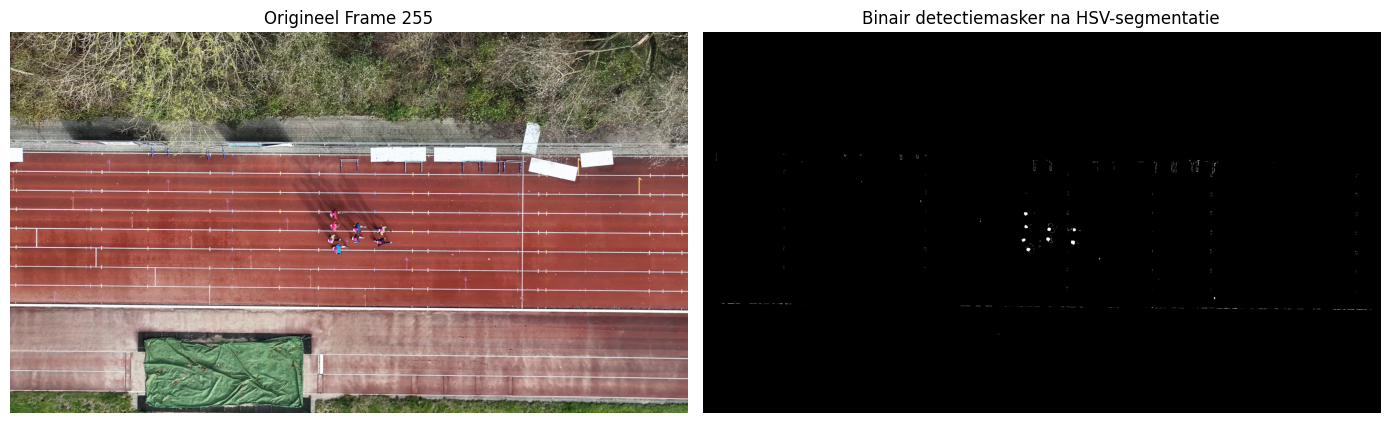

In [6]:
# Visualisatie van het originele frame naast het binaire masker (voor de thesis)
EXPORT_FRAME = 255

cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, EXPORT_FRAME)
ret, frame = cap.read()
cap.release()

if ret:
    blurred = cv2.GaussianBlur(frame, (5, 5), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, np.array([140, 50, 50]), np.array([165, 255, 255]))
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    ax[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax[0].set_title(f"Origineel Frame {EXPORT_FRAME}")
    ax[0].axis("off")
    
    ax[1].imshow(mask, cmap="gray")
    ax[1].set_title("Binair detectiemasker na HSV-segmentatie")
    ax[1].axis("off")
    
    plt.tight_layout()
    plt.show()